In [1]:
# Diffusion model dependencies (TabDDPM + ForestDiffusion)
# TabDDPM: yandex-research/tab-ddpm (_vendor/tab-ddpm)
# ForestDiffusion: pip install ForestDiffusion
# libzero/rtdl pin torch<2; use --no-deps on torch 2.x (TabDDPM still works)
%pip install -q ForestDiffusion xgboost category-encoders imbalanced-learn absl-py tensorboardX icecream dython optuna skorch pyarrow tomli tomli-w
%pip install -q "pynvml>=11,<12"
%pip install -q "libzero==0.0.8" "rtdl==0.0.13" --no-deps

import sys
from pathlib import Path

NOTEBOOK_DIR = Path(".").resolve()
DIFFUSION_PKG = NOTEBOOK_DIR.parent
_repo = NOTEBOOK_DIR
while not (_repo / "_vendor" / "tab-ddpm").is_dir() and _repo.parent != _repo:
    _repo = _repo.parent
REPO_ROOT = _repo
if not (REPO_ROOT / "_vendor" / "tab-ddpm").is_dir():
    raise FileNotFoundError(
        "Missing _vendor/tab-ddpm. Clone per README: "
        "git clone https://github.com/yandex-research/tab-ddpm _vendor/tab-ddpm"
    )
sys.path.insert(0, str(REPO_ROOT / "_vendor" / "tab-ddpm"))
sys.path.insert(0, str(REPO_ROOT / "_vendor" / "tab-ddpm" / "scripts"))
sys.path.insert(0, str(DIFFUSION_PKG))

from diffusion_generators import train_tabddpm, train_forestdiffusion


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split

from sdv.metadata import SingleTableMetadata
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality

# ----------------------------------------------------
# Load Dataset
# ----------------------------------------------------
metro_interstate_traffic_volume = fetch_ucirepo(id=492)

X = metro_interstate_traffic_volume.data.features.copy()
y = metro_interstate_traffic_volume.data.targets.copy()

# Drop date_time before any preprocessing or generator training.
X = X.drop(columns=['date_time'], errors='ignore')

print(metro_interstate_traffic_volume.metadata)
print(metro_interstate_traffic_volume.variables)

if isinstance(y, pd.DataFrame):
    if 'traffic_volume' in y.columns:
        target_col = 'traffic_volume'
    else:
        target_col = y.columns[0]
    y_series = y[target_col]
else:
    target_col = 'traffic_volume'
    y_series = pd.Series(y, name=target_col)

{'uci_id': 492, 'name': 'Metro Interstate Traffic Volume', 'repository_url': 'https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume', 'data_url': 'https://archive.ics.uci.edu/static/public/492/data.csv', 'abstract': 'Hourly Minneapolis-St Paul, MN traffic volume for westbound I-94. Includes weather and holiday features from 2012-2018.', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 48204, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['traffic_volume'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C5X60B', 'creators': ['John Hogue'], 'intro_paper': None, 'additional_info': {'summary': 'Hourly Interstate 94 Westbound traffic volume for MN DoT ATR station 301, roughly midway between Minneapolis and St Paul, MN. Hourly weath

In [3]:
# ----------------------------------------------------
# Preprocess features before synthetic data generation
# ----------------------------------------------------
# 1. Drop the date_time column from the dataset
# 2. Keep raw columns for TabDDPM
# 3. One-hot encode categoricals for WGAN / SDV / downstream ML
# ----------------------------------------------------

# Drop date_time (hour of data collected in local CST time).
X = X.drop(columns=['date_time'], errors='ignore')

# Raw tabular features for TabDDPM (expects categorical column names, not dummies).
X_ctab = X.copy()
for col in ['temp', 'rain_1h', 'snow_1h', 'clouds_all']:
    X_ctab[col] = pd.to_numeric(X_ctab[col], errors='coerce')
metro_data_ctab = pd.concat([X_ctab, y_series.reset_index(drop=True)], axis=1)
metro_data_ctab[target_col] = pd.to_numeric(metro_data_ctab[target_col], errors='coerce').fillna(0)
for col in ['holiday', 'weather_main', 'weather_description']:
    metro_data_ctab[col] = metro_data_ctab[col].fillna('None').astype(str)

# One-hot encode categorical columns for other generators.
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

metro_data = pd.concat([X, y_series.reset_index(drop=True)], axis=1)
metro_data = metro_data.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float64)

print(f'Target variable: {target_col}')
print(f'date_time in features: {"date_time" in metro_data.columns}')
print(f'Encoded dataset shape: {metro_data.shape}')
print(f'TabDDPM raw dataset shape: {metro_data_ctab.shape}')

Target variable: traffic_volume
date_time in features: False
Encoded dataset shape: (48204, 62)
TabDDPM raw dataset shape: (48204, 8)


In [4]:
# ----------------------------------------------------
# Experiment Settings
# ----------------------------------------------------
N_SAMPLES = 1000          # random real samples drawn from full dataset
TEST_SIZE = 0.2           # 20% holdout for unseen TSTR evaluation
SEED = 42

# Speed controls (set FAST_MODE=False for full paper epochs)
FAST_MODE = True
DEV_MODE = False
RUN_QUALITY_EVAL = True

N_SYNTH_SAMPLES = 1000

_epoch_fast = 5 if FAST_MODE else None
TabDDPM_EPOCHS = _epoch_fast if FAST_MODE else 150
WGAN_EPOCHS = (10 if FAST_MODE else 100)  # WGAN needs more epochs on high-dim one-hot data
SDV_EPOCHS = _epoch_fast if FAST_MODE else 300

EVAL_SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

ALL_GENERATORS = [
    'CTGAN', 'CopulaGAN', 'TVAE', 'GaussianCopula', 'TabDDPM', 'ForestDiffusion'
]
GENERATORS_TO_EVAL = ALL_GENERATORS

# Randomly select 1000 samples from the full preprocessed dataset.
_sample_idx = metro_data.sample(n=N_SAMPLES, random_state=SEED).index
metro_data = metro_data.loc[_sample_idx].reset_index(drop=True)
metro_data_ctab = metro_data_ctab.loc[_sample_idx].reset_index(drop=True)

# 80% for generator training, 20% held out unseen for TSTR evaluation.
train_real, test_real = train_test_split(
    metro_data,
    test_size=TEST_SIZE,
    random_state=SEED,
)
train_real_ctab, test_real_ctab = train_test_split(
    metro_data_ctab,
    test_size=TEST_SIZE,
    random_state=SEED,
)
train_real = train_real.reset_index(drop=True)
test_real = test_real.reset_index(drop=True)
train_real_ctab = train_real_ctab.reset_index(drop=True)
test_real_ctab = test_real_ctab.reset_index(drop=True)

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(train_real)
train_metadata = metadata

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

scores = {}
synthetic_datasets = {}
quality_results = []


def align_to_train_schema(df, reference_df, label_col):
    """Map raw or mixed-type rows to the one-hot numeric schema used by train_real."""
    df = df.copy()
    y = pd.to_numeric(df[label_col], errors='coerce').fillna(0)
    X = df.drop(columns=[label_col], errors='ignore')
    X_ref = reference_df.drop(columns=[label_col], errors='ignore')

    if X.select_dtypes(include=['object', 'string', 'category']).shape[1] > 0:
        X = pd.get_dummies(X, drop_first=True)

    X = X.reindex(columns=X_ref.columns, fill_value=0)
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float64)

    out = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
    out.columns = reference_df.columns
    return out


print(f'Random subsample: {metro_data.shape}')
print(f'Generator training set (80%): {train_real.shape}')
print(f'Holdout test set (20%, unseen): {test_real.shape}')
print(f'DEV_MODE: {DEV_MODE} | FAST_MODE: {FAST_MODE} | quality eval: {RUN_QUALITY_EVAL}')
print(f'Generators enabled: {GENERATORS_TO_EVAL}')
print(f'Synthetic samples per generator: {N_SYNTH_SAMPLES}')


Random subsample: (1000, 62)
Generator training set (80%): (800, 62)
Holdout test set (20%, unseen): (200, 62)
DEV_MODE: False | FAST_MODE: True | quality eval: True
Generators enabled: ['CTGAN', 'CopulaGAN', 'TVAE', 'GaussianCopula', 'TabDDPM', 'ForestDiffusion']
Synthetic samples per generator: 1000


In [5]:
# ---------------------------------------------------
# SINGLE RUN — setup + TabDDPM
# ---------------------------------------------------
seed = SEED
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Train generators on 80% of the 1000-sample subset only.

# TabDDPM — train on raw categoricals (not one-hot encoded)
# Use holiday + weather_main only (weather_description is too high-cardinality
# for 800-row train split and triggers Cond/log errors in TabDDPM+).

if 'TabDDPM' in GENERATORS_TO_EVAL:
    import traceback
    try:
        print('Training TabDDPM...')
        synthetic_tabddpm = train_tabddpm(
            train_real_ctab,
            target_col=target_col,
            categorical_columns=['holiday', 'weather_main'],
            n_samples=N_SYNTH_SAMPLES,
            seed=seed,
        )
        synthetic_datasets['TabDDPM'] = synthetic_tabddpm.copy()
        if RUN_QUALITY_EVAL:
            quality = evaluate_quality(
                real_data=train_real,
                synthetic_data=align_to_train_schema(synthetic_tabddpm, train_real, target_col),
                metadata=train_metadata,
            )
            scores['TabDDPM'] = quality.get_score()
            print('TabDDPM:', round(scores['TabDDPM'], 4))
        else:
            print('TabDDPM: trained (quality eval skipped)')
    except Exception as e:
        print('TabDDPM Failed:', e)
        traceback.print_exc()
else:
    print('TabDDPM: skipped (not in GENERATORS_TO_EVAL)')
    




Training TabDDPM...
[0]
41
{'num_classes': 0, 'is_y_cond': False, 'rtdl_params': {'d_layers': [256, 256, 256], 'dropout': 0.0}, 'd_in': np.int64(41)}
mlp
Step 500/1000 MLoss: 0.0 GLoss: 0.1909 Sum: 0.1909
Step 1000/1000 MLoss: 0.0 GLoss: 0.1517 Sum: 0.1517
mlp
Sample timestep    0
Discrete cols: [3]
Num shape:  (1000, 4)
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 62/62 [00:00<00:00, 1343.04it/s]|
Column Shapes Score: 93.99%

(2/2) Evaluating Column Pair Trends: |██████████| 1891/1891 [00:03<00:00, 560.60it/s]|
Column Pair Trends Score: 70.82%

Overall Score (Average): 82.4%

TabDDPM: 0.824


In [6]:
# ForestDiffusion — regression: model target jointly (not via label_y).
# Drop weather_description (high cardinality; same rationale as TabDDPM).
if "ForestDiffusion" in GENERATORS_TO_EVAL:
    import traceback
    try:
        _fd_train = train_real_ctab.drop(columns=["weather_description"], errors="ignore")
        print("Training ForestDiffusion...")
        print(f"ForestDiffusion fast_mode={FAST_MODE}")
        synthetic_forestdiffusion = train_forestdiffusion(
            _fd_train,
            target_col=target_col,
            categorical_columns=["holiday", "weather_main"],
            n_samples=N_SYNTH_SAMPLES,
            seed=seed,
            fast_mode=FAST_MODE,
            is_regression=True,
        )
        synthetic_datasets["ForestDiffusion"] = synthetic_forestdiffusion.copy()
        print("ForestDiffusion: synthesis complete")
        if RUN_QUALITY_EVAL:
            quality = evaluate_quality(
                real_data=train_real,
                synthetic_data=align_to_train_schema(synthetic_forestdiffusion, train_real, target_col),
                metadata=train_metadata,
            )
            scores["ForestDiffusion"] = quality.get_score()
            print("ForestDiffusion:", round(scores["ForestDiffusion"], 4))
        else:
            print("ForestDiffusion: trained (quality eval skipped)")
    except Exception as e:
        print("ForestDiffusion Failed (training/sampling):")
        traceback.print_exc()
else:
    print("ForestDiffusion: skipped (not in GENERATORS_TO_EVAL)")


Training ForestDiffusion...
ForestDiffusion fast_mode=True
ForestDiffusion fast_mode: n_t=8, duplicate_K=10, n_estimators=30, max_depth=5, n_jobs=4, gpu_hist=True
ForestDiffusion: synthesis complete
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 62/62 [00:00<00:00, 1548.67it/s]|
Column Shapes Score: 95.8%

(2/2) Evaluating Column Pair Trends: |██████████| 1891/1891 [00:03<00:00, 561.13it/s]|
Column Pair Trends Score: 85.26%

Overall Score (Average): 90.53%

ForestDiffusion: 0.9053


In [9]:
# Quality summary
quality_results = []
for gen_name in GENERATORS_TO_EVAL:
    quality_results.append({
        'Generator': gen_name,
        'Quality_Score': scores.get(gen_name, np.nan),
        'Status': 'Success' if gen_name in synthetic_datasets else 'Failed'
    })

quality_df = pd.DataFrame(quality_results).sort_values('Quality_Score', ascending=False)
display(quality_df)

,Generator,Quality_Score,Status
5,ForestDiffusion,0.905327,Success
4,TabDDPM,0.824034,Success
0,CTGAN,NaN,Failed
1,CopulaGAN,NaN,Failed
2,TVAE,NaN,Failed
3,GaussianCopula,NaN,Failed


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 61/61 [00:00<00:00, 1427.80it/s]|
Column Shapes Score: 94.79%

(2/2) Evaluating Column Pair Trends: |██████████| 1830/1830 [00:03<00:00, 562.50it/s]|
Column Pair Trends Score: 70.82%

Overall Score (Average): 82.8%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 61/61 [00:00<00:00, 1544.65it/s]|
Column Shapes Score: 95.89%

(2/2) Evaluating Column Pair Trends: |██████████| 1830/1830 [00:03<00:00, 552.79it/s]|
Column Pair Trends Score: 85.26%

Overall Score (Average): 90.57%



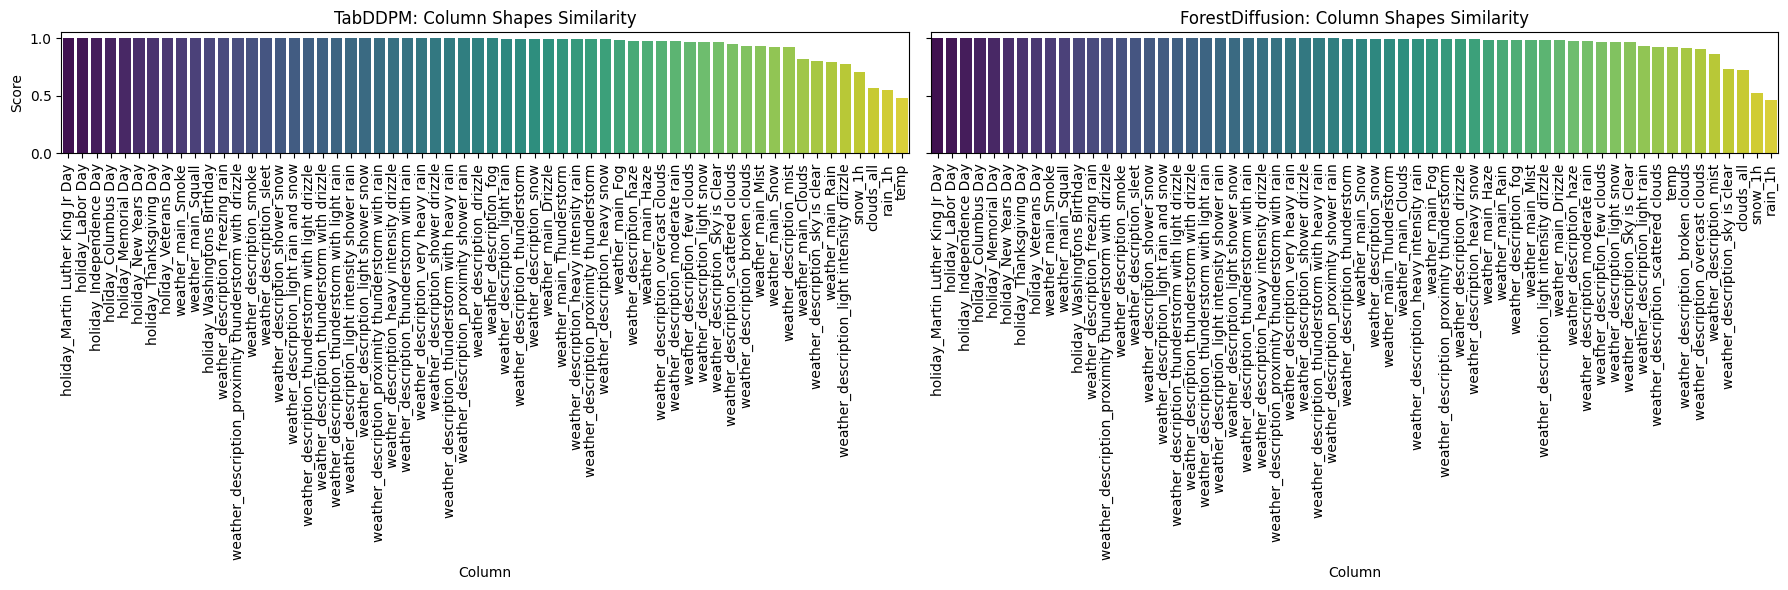

,Column,Metric,Score,Model
0,holiday_Martin Luther King Jr Day,TVComplement,1.0,TabDDPM
1,holiday_Labor Day,TVComplement,1.0,TabDDPM
2,holiday_Independence Day,TVComplement,1.0,TabDDPM
3,holiday_Columbus Day,TVComplement,1.0,TabDDPM
4,holiday_Memorial Day,TVComplement,1.0,TabDDPM
5,holiday_New Years Day,TVComplement,1.0,TabDDPM
6,holiday_Thanksgiving Day,TVComplement,1.0,TabDDPM
7,holiday_Veterans Day,TVComplement,1.0,TabDDPM
8,weather_main_Smoke,TVComplement,1.0,TabDDPM
9,weather_main_Squall,TVComplement,1.0,TabDDPM


In [11]:
# ---------------------------------------------------
# Column Shapes Quality Report (per generator)
# ---------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns

# Generators to compare (only those with synthetic output available).
model_order = [m for m in ['TabDDPM', 'ForestDiffusion'] if m in synthetic_datasets]

if not model_order:
    print('No synthetic datasets available for column-shape comparison.')
else:
    real_eval = train_real.drop(columns=[target_col], errors='ignore').copy()

    metadata_eval = SingleTableMetadata()
    metadata_eval.detect_from_dataframe(real_eval)

    column_shape_details = {}

    for model_name in model_order:
        synth_aligned = align_to_train_schema(
            synthetic_datasets[model_name], train_real, target_col
        )
        synth_eval = synth_aligned.drop(columns=[target_col], errors='ignore').copy()

        qr = QualityReport()
        qr.generate(
            real_data=real_eval,
            synthetic_data=synth_eval,
            metadata=metadata_eval.to_dict()
        )

        details = qr.get_details('Column Shapes').sort_values('Score', ascending=False)
        column_shape_details[model_name] = details

    fig, axes = plt.subplots(1, len(model_order), figsize=(9 * len(model_order), 6), sharey=True)
    if len(model_order) == 1:
        axes = [axes]

    for ax, model_name in zip(axes, model_order):
        details = column_shape_details[model_name]

        sns.barplot(
            x='Column',
            y='Score',
            data=details,
            palette='viridis',
            ax=ax
        )

        ax.set_title(f'{model_name}: Column Shapes Similarity')
        ax.tick_params(axis='x', rotation=90)
        ax.set_xlabel('Column')
        ax.set_ylabel('Score')

    plt.tight_layout()
    plt.show()

    combined_details = pd.concat(
        [df.assign(Model=name) for name, df in column_shape_details.items()],
        ignore_index=True
    )

    display(combined_details.head(20))

In [18]:
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

regressors = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
    'SVR_RBF': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoost': GradientBoostingRegressor(random_state=42),
}

print(f'Regression evaluation: {len(regressors)} models, {len(EVAL_SEEDS)} seeds, {len(GENERATORS_TO_EVAL)} generators')


Regression evaluation: 10 models, 10 seeds, 6 generators


In [19]:
from sklearn.preprocessing import StandardScaler

def evaluate_regression_models(train_df, test_df, label_col, models, test_size=0.2, seeds=None, use_holdout=False, schema_df=None):
    if seeds is None:
        seeds = EVAL_SEEDS
    if schema_df is None:
        schema_df = test_df if use_holdout else train_df

    train_df = align_to_train_schema(train_df, schema_df, label_col)
    test_df = align_to_train_schema(test_df, schema_df, label_col)

    def _std(values):
        return float(np.std(values, ddof=1)) if len(values) > 1 else 0.0

    results = []

    for name, model in models.items():
        print(f"  {name}...", flush=True)
        r2_scores = []
        mse_scores = []
        rmse_scores = []
        mae_scores = []

        for seed in seeds:
            X_train = train_df.drop(columns=[label_col])
            y_train = train_df[label_col]
            X_test = test_df.drop(columns=[label_col])
            y_test = test_df[label_col]

            if use_holdout:
                # Fixed holdout test; bootstrap rows per seed for meaningful std.
                rng = np.random.default_rng(seed)
                train_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
                test_idx = rng.choice(len(X_test), size=len(X_test), replace=True)
                X_train = X_train.iloc[train_idx].reset_index(drop=True)
                y_train = y_train.iloc[train_idx].reset_index(drop=True)
                X_test = X_test.iloc[test_idx].reset_index(drop=True)
                y_test = y_test.iloc[test_idx].reset_index(drop=True)
            else:
                X_train, _, y_train, _ = train_test_split(
                    X_train, y_train, test_size=test_size, random_state=seed
                )
                _, X_test, _, y_test = train_test_split(
                    X_test, y_test, test_size=test_size, random_state=seed
                )

            scaler = StandardScaler()
            X_train_s = scaler.fit_transform(X_train)
            X_test_s = scaler.transform(X_test)

            reg = clone(model)
            if "random_state" in reg.get_params():
                reg.set_params(random_state=seed)

            reg.fit(X_train_s, y_train)
            y_pred = reg.predict(X_test_s)

            mse = mean_squared_error(y_test, y_pred)
            r2_scores.append(r2_score(y_test, y_pred))
            mse_scores.append(mse)
            rmse_scores.append(np.sqrt(mse))
            mae_scores.append(mean_absolute_error(y_test, y_pred))

        results.append({
            "Model": name,
            "R2 Mean": np.mean(r2_scores),
            "R2 Std": _std(r2_scores),
            "MSE Mean": np.mean(mse_scores),
            "MSE Std": _std(mse_scores),
            "RMSE Mean": np.mean(rmse_scores),
            "RMSE Std": _std(rmse_scores),
            "MAE Mean": np.mean(mae_scores),
            "MAE Std": _std(mae_scores),
            "R2 (Mean±Std)": f"{np.mean(r2_scores):.4f} ± {_std(r2_scores):.4f}",
            "MSE (Mean±Std)": f"{np.mean(mse_scores):.4f} ± {_std(mse_scores):.4f}",
            "RMSE (Mean±Std)": f"{np.mean(rmse_scores):.4f} ± {_std(rmse_scores):.4f}",
            "MAE (Mean±Std)": f"{np.mean(mae_scores):.4f} ± {_std(mae_scores):.4f}",
        })

    return pd.DataFrame(results).sort_values(by="R2 Mean", ascending=False)


In [20]:
print('TRTR (Train Real, Test Real) — 80% train / 20% holdout')
trtr_results = evaluate_regression_models(
    train_df=train_real,
    test_df=test_real,
    label_col=target_col,
    models=regressors,
    seeds=EVAL_SEEDS,
    use_holdout=True,
    schema_df=train_real,
)
display(trtr_results[['Model', 'R2 (Mean±Std)', 'MSE (Mean±Std)', 'RMSE (Mean±Std)', 'MAE (Mean±Std)']])

all_comparisons = []
for synth_name in GENERATORS_TO_EVAL:
    if synth_name not in synthetic_datasets:
        print(f'Skipping {synth_name} - no synthetic dataset')
        continue

    print(f'{synth_name} - TSTR (train on synthetic, test on 20% holdout)')
    tstr_results = evaluate_regression_models(
        train_df=synthetic_datasets[synth_name],
        test_df=test_real,
        label_col=target_col,
        models=regressors,
        seeds=EVAL_SEEDS,
        use_holdout=True,
        schema_df=train_real,
    )
    display(tstr_results[['Model', 'R2 (Mean±Std)', 'MSE (Mean±Std)', 'RMSE (Mean±Std)', 'MAE (Mean±Std)']])

    comparison = trtr_results.merge(tstr_results, on='Model', suffixes=('_TRTR', '_TSTR'))
    comparison['R2_Drop'] = comparison['R2 Mean_TRTR'] - comparison['R2 Mean_TSTR']
    comparison['MSE_Increase'] = comparison['MSE Mean_TSTR'] - comparison['MSE Mean_TRTR']
    comparison['RMSE_Increase'] = comparison['RMSE Mean_TSTR'] - comparison['RMSE Mean_TRTR']
    comparison['MAE_Increase'] = comparison['MAE Mean_TSTR'] - comparison['MAE Mean_TRTR']
    comparison['Synthetic_Model'] = synth_name
    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)
summary = (
    combined_comparison
    .groupby('Synthetic_Model', as_index=False)[['R2_Drop', 'MSE_Increase', 'RMSE_Increase', 'MAE_Increase']]
    .mean()
    .sort_values('R2_Drop')
)

display(summary)


TRTR (Train Real, Test Real) — 80% train / 20% holdout
  LinearRegression...
  Ridge...
  Lasso...
  ElasticNet...
  SVR_RBF...
  KNN...
  DecisionTree...
  RandomForest...
  ExtraTrees...
  GradientBoost...


,Model,R2 (Mean±Std),MSE (Mean±Std),RMSE (Mean±Std),MAE (Mean±Std)
1,Ridge,-0.0220 ± 0.0931,4190833.0051 ± 338025.6045,2045.7231 ± 80.6224,1765.5288 ± 49.6109
3,ElasticNet,-0.0220 ± 0.0933,4191008.9406 ± 338623.7087,2045.7612 ± 80.7598,1765.4563 ± 49.7100
0,LinearRegression,-0.0220 ± 0.0934,4191091.4209 ± 339054.5695,2045.7778 ± 80.8599,1765.3935 ± 49.7724
2,Lasso,-0.0236 ± 0.0956,4197301.3612 ± 344679.8162,2047.2467 ± 82.2072,1766.7192 ± 51.5748
9,GradientBoost,-0.0294 ± 0.0701,4222447.8456 ± 248994.8518,2054.0512 ± 60.7502,1794.7160 ± 61.2286
4,SVR_RBF,-0.0452 ± 0.0297,4292253.0018 ± 201312.7536,2071.2596 ± 48.7265,1855.6813 ± 44.4818
5,KNN,-0.2675 ± 0.1103,5199525.5145 ± 418987.0960,2278.5802 ± 91.8795,1930.9040 ± 87.7957
7,RandomForest,-0.3361 ± 0.1378,5484008.1682 ± 576403.3612,2338.8174 ± 124.4601,1976.3517 ± 123.2861
8,ExtraTrees,-0.5096 ± 0.1767,6200940.9657 ± 777167.7922,2485.6744 ± 157.6351,2051.1804 ± 176.3900
6,DecisionTree,-0.9240 ± 0.2197,7901767.6352 ± 957048.7890,2806.0200 ± 176.4436,2255.2110 ± 191.7410


Skipping CTGAN - no synthetic dataset
Skipping CopulaGAN - no synthetic dataset
Skipping TVAE - no synthetic dataset
Skipping GaussianCopula - no synthetic dataset
TabDDPM - TSTR (train on synthetic, test on 20% holdout)
  LinearRegression...
  Ridge...
  Lasso...
  ElasticNet...
  SVR_RBF...
  KNN...
  DecisionTree...
  RandomForest...
  ExtraTrees...
  GradientBoost...


,Model,R2 (Mean±Std),MSE (Mean±Std),RMSE (Mean±Std),MAE (Mean±Std)
9,GradientBoost,-0.1264 ± 0.1222,4687055.0478 ± 418304.8650,2162.9610 ± 98.0644,1823.8288 ± 83.1129
7,RandomForest,-0.3081 ± 0.1667,5456958.8369 ± 759922.2469,2331.3502 ± 155.5105,1935.3900 ± 129.4927
5,KNN,-0.5094 ± 0.2414,6260363.1055 ± 802186.6645,2497.4711 ± 159.8649,2070.2848 ± 120.6611
8,ExtraTrees,-0.5882 ± 0.2621,6617697.3760 ± 1078627.2818,2565.2560 ± 203.1935,2094.3190 ± 146.7954
1,Ridge,-0.7179 ± 0.1894,7148589.7060 ± 652247.6626,2671.1324 ± 123.1132,2269.5774 ± 99.0715
3,ElasticNet,-0.7189 ± 0.1900,7152739.7863 ± 654933.5699,2671.8895 ± 123.5855,2270.1114 ± 99.3818
2,Lasso,-0.7199 ± 0.1906,7156906.2941 ± 657659.5463,2672.6491 ± 124.0648,2270.6458 ± 99.6912
0,LinearRegression,-0.7199 ± 0.1906,7156929.2717 ± 657674.2477,2672.6533 ± 124.0674,2270.6491 ± 99.6931
6,DecisionTree,-0.9207 ± 0.1346,8009991.0330 ± 616382.3817,2828.2594 ± 110.2513,2273.1323 ± 88.6322
4,SVR_RBF,-1.5851 ± 0.2431,10768783.0252 ± 929400.1443,3278.8528 ± 141.0571,2570.1181 ± 172.8450


ForestDiffusion - TSTR (train on synthetic, test on 20% holdout)
  LinearRegression...
  Ridge...
  Lasso...
  ElasticNet...
  SVR_RBF...
  KNN...
  DecisionTree...
  RandomForest...
  ExtraTrees...
  GradientBoost...


,Model,R2 (Mean±Std),MSE (Mean±Std),RMSE (Mean±Std),MAE (Mean±Std)
1,Ridge,0.0065 ± 0.0489,4146450.4834 ± 304542.6127,2035.0490 ± 74.7280,1813.9327 ± 87.4034
3,ElasticNet,0.0064 ± 0.0489,4146501.1734 ± 304493.1543,2035.0619 ± 74.7154,1813.9233 ± 87.3894
2,Lasso,0.0064 ± 0.0489,4146552.2122 ± 304443.5293,2035.0749 ± 74.7028,1813.9138 ± 87.3754
0,LinearRegression,0.0064 ± 0.0489,4146554.1279 ± 304442.9847,2035.0754 ± 74.7026,1813.9136 ± 87.3751
4,SVR_RBF,-0.1194 ± 0.0548,4673397.5060 ± 365366.9216,2160.3407 ± 83.8366,1913.1912 ± 96.8101
9,GradientBoost,-0.1299 ± 0.1201,4710666.8682 ± 519132.5854,2167.5801 ± 116.7307,1907.2409 ± 97.2838
7,RandomForest,-0.1921 ± 0.1004,4977471.6048 ± 526704.1129,2228.3758 ± 114.5659,1936.3711 ± 104.3496
5,KNN,-0.2011 ± 0.0695,5009603.7377 ± 344676.7246,2237.0389 ± 76.4525,1921.6000 ± 75.1844
8,ExtraTrees,-0.2198 ± 0.0799,5093951.6703 ± 471205.5773,2254.8586 ± 103.0865,1939.8228 ± 91.8653
6,DecisionTree,-0.7328 ± 0.1756,7224309.4918 ± 769090.7853,2684.4813 ± 140.9076,2209.6820 ± 124.9356


,Synthetic_Model,R2_Drop,MSE_Increase,RMSE_Increase,MAE_Increase
0,ForestDiffusion,-0.063193,-1.795719e+05,-34.597499,15.644918
1,TabDDPM,0.471294,2.034484e+06,413.356325,292.091472


In [21]:
output_file = 'TRTR_TSTR_results_regression.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    quality_df.to_excel(writer, sheet_name='Quality_Metrics', index=False)
    trtr_results.to_excel(writer, sheet_name='TRTR_Results', index=False)
    combined_comparison.to_excel(writer, sheet_name='All_Comparisons', index=False)
    summary.to_excel(writer, sheet_name='Summary', index=False)
    for synth_name in GENERATORS_TO_EVAL:
        if synth_name in combined_comparison['Synthetic_Model'].values:
            synth_results = combined_comparison[combined_comparison['Synthetic_Model'] == synth_name]
            synth_results.to_excel(writer, sheet_name=synth_name[:31], index=False)

print(f'Results saved to: {output_file}')


Results saved to: TRTR_TSTR_results_regression.xlsx
